# 00 — How the complete FRTB SA calculation works

Build a mental map of the entire Standardised Approach before calculating any number.

The Fundamental Review of the Trading Book (FRTB) Standardised Approach (SA) has three capital components. The Sensitivities-based Method (SBM) measures ordinary market movements, the Default Risk Charge (DRC) measures jump-to-default loss, and the Residual Risk Add-on (RRAO) captures specified risks not adequately represented by sensitivities.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns, display_sample,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260908T033903126517Z


This is the part of the calculation chain being handled here:

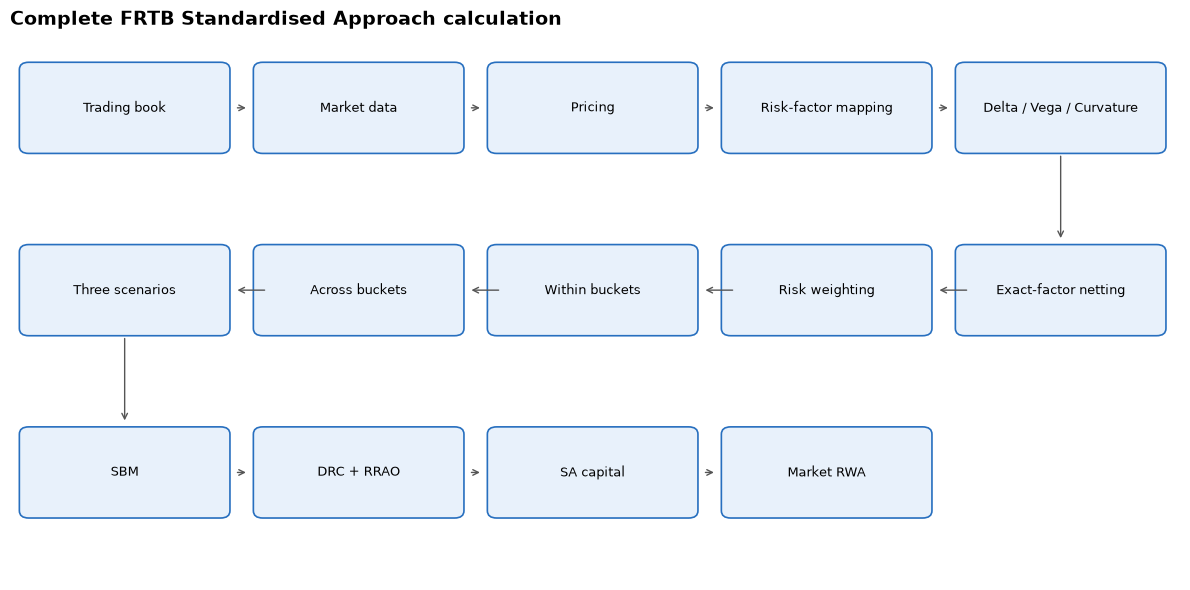

In [2]:
draw_flow(['Trading book', 'Market data', 'Pricing', 'Risk-factor mapping', 'Delta / Vega / Curvature', 'Exact-factor netting', 'Risk weighting', 'Within buckets', 'Across buckets', 'Three scenarios', 'SBM', 'DRC + RRAO', 'SA capital', 'Market RWA'],'Complete FRTB Standardised Approach calculation',wrap_after=5)

One synthetic trading book is priced in Indian rupees (INR). Trades are mapped to factors; sensitivities are calculated by repricing; SBM aggregates them through exact-factor netting, risk weights, buckets and three correlation scenarios. DRC and RRAO are calculated separately and added at the end.

$$\text{FRTB SA capital}=\text{SBM}+\text{DRC}+\text{RRAO}$$

$$\text{Market RWA}=12.5\times\text{FRTB SA capital}$$

In [3]:
summary=json.loads((RUN/'16_capital_summary.json').read_text())
classes=['GIRR','CSR non-securitisation','CSR securitisation non-CTP',
         'CSR securitisation CTP','Equity','Commodity','FX']
print('The seven SBM risk classes are:')
for position,name in enumerate(classes,1): print(f'{position}. {name}')
print()
print(f"Synthetic trades: {summary['synthetic_trade_count']}")
print(f"Reporting currency: {summary['reporting_currency']}")

The seven SBM risk classes are:
1. GIRR
2. CSR non-securitisation
3. CSR securitisation non-CTP
4. CSR securitisation CTP
5. Equity
6. Commodity
7. FX

Synthetic trades: 48
Reporting currency: INR


The visual below uses the calculated rows shown above.

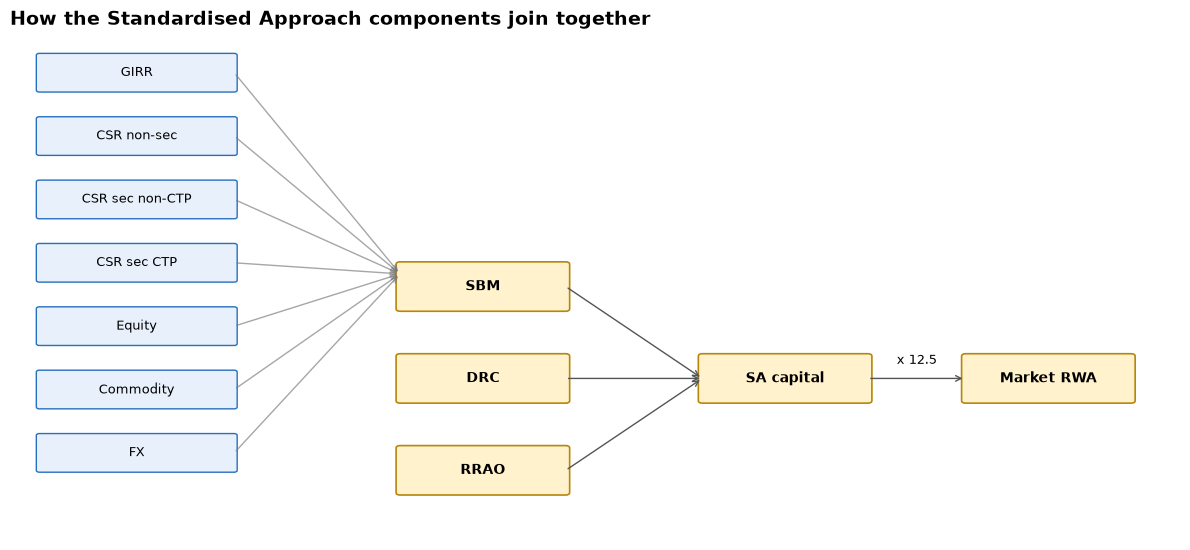

In [4]:
draw_capital_map()

Read the notebooks in number order. Each performs one visible transformation needed by the next stage.